# MACD Model

In [ ]:
# Import libraries
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set our time window
start_date = '2021-11-12'
end_date = '2022-12-30'
 
# Type in any ticker to analyze its behavior against our strategy
ticker = 'ARKK'
df = yf.download(ticker, start_date, end_date)

# Define our weighted windows, giving us our MACD
df['EMA12'] = df['Close'].ewm(span=12, adjust=False).mean()
df['EMA26'] = df['Close'].ewm(span=26, adjust=False).mean()
# Define our MACD, Signal (crossover line), and Histogram
df['MACD'] = df['EMA12'] - df['EMA26']
df['Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()
df['Hist'] = df['MACD'] - df['Signal']

# Create crossover signal points
df['MACD_prev'] = df['MACD'].shift(1)
df['Signal_prev'] = df['Signal'].shift(1)

# Create our signals for plotting purposes
df['BuySignal']  = (df['MACD_prev'] < df['Signal_prev']) & (df['MACD'] >= df['Signal'])
df['SellSignal'] = (df['MACD_prev'] > df['Signal_prev']) & (df['MACD'] <= df['Signal'])

[*********************100%***********************]  1 of 1 completed


### Plot Trends

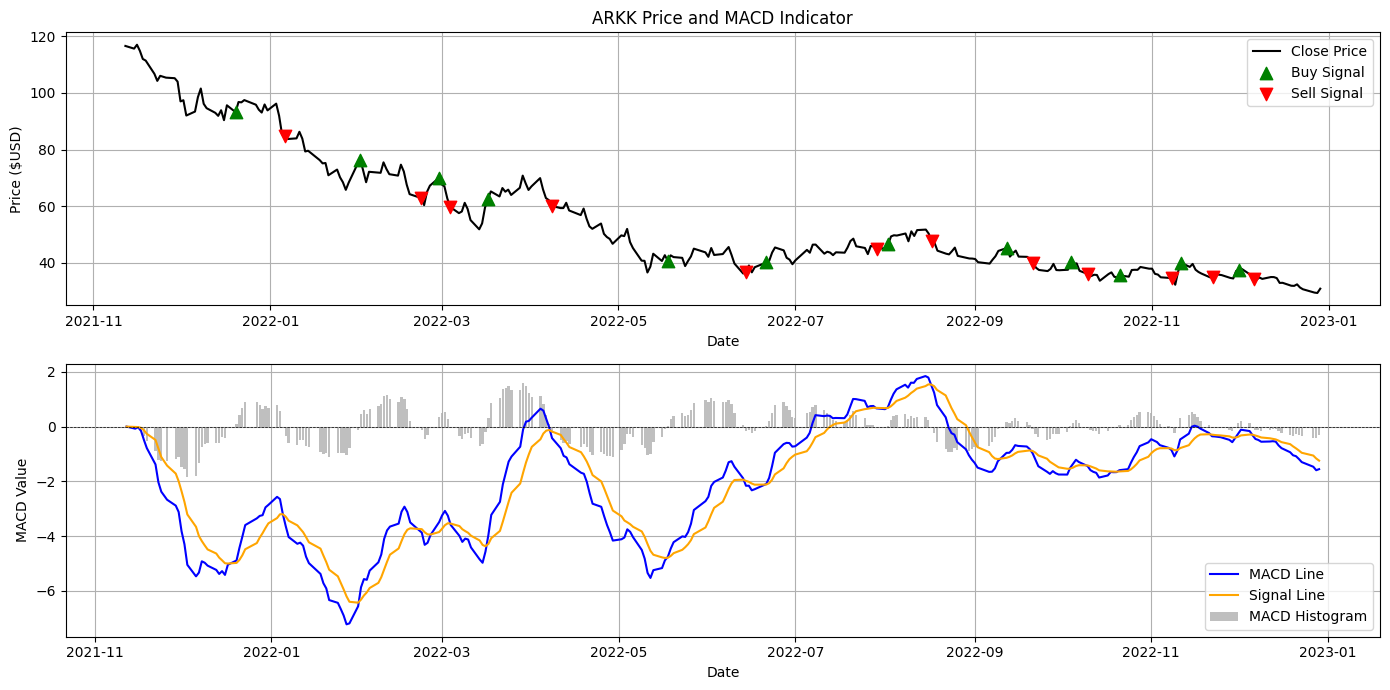

In [ ]:
plt.figure(figsize=(14, 7))

# Subplot 1: Price
plt.subplot(2, 1, 1)
plt.plot(df['Close'], label='Close Price', color='black')
plt.title(f'{ticker} Price and MACD Indicator')
plt.ylabel('Price ($USD)')
plt.xlabel('Date')
plt.grid(True)

# Add crossover-based buy/sell markers
plt.scatter(df.index[df['BuySignal']], df['Close'][df['BuySignal']], 
            label='Buy Signal', marker='^', color='green', s=80, zorder=10)

plt.scatter(df.index[df['SellSignal']], df['Close'][df['SellSignal']], 
            label='Sell Signal', marker='v', color='red', s=80, zorder=10)

plt.legend()

# Subplot 2: MACD components
plt.subplot(2, 1, 2)
plt.plot(df['MACD'], label='MACD Line', color='blue')
plt.plot(df['Signal'], label='Signal Line', color='orange')
plt.bar(df.index, df['Hist'], label='MACD Histogram', color='grey', alpha=0.5)
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.ylabel('MACD Value')
plt.xlabel('Date')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
